<a href="https://colab.research.google.com/github/andyotani/andyotani-PCVK_Ganjil_26-27/blob/main/Jobsheet03/JS03_pcvk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Modul 3 – Operasi Citra Sederhana**

**PRAKTIKUM**

D1. Operasi Citra Sederhana

1. Buka https://colab.research.google.com/, pilih tab Github dan pastikan repository yang
terpilih ada repository yang sama dengan praktikum pada minggu pertama dan kedua.
Lanjutkan dengan membuat notebook baru dan ubah nama file menjadi “JS03_pcvk.ipynb”.
Perhatian: Jangan lupa untuk menyimpan salinan ke Github setelah melakukan
perubahan / ketika Anda sudah selesai melakukan praktikum.
2. Akses folder images pada Google Drive Anda dengan kode berikut:



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Ikuti alur autorisasinya hingga muncul pesan: “Mounted at /content/drive”.

3. Melakukan transformasi linier brightness dengan memasukkan nilai konstanta tertentu
dan menghasilkan warna. Seperti yang telah dibahas pada ulasan teori, formula untuk
melakukan transformasi linier brightness adalah sebagai berikut:
 **g(x, y) = f(x, y) + b
dimana g(x,y)** adalah nilai pixel setelah transformasi, f(x,y)
adalah nilai pixel asli, dan b
adalah nilai brightness.
Tuliskan potongan kode berikut untuk mengimplementasikan linier brightness pada
google colab:

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving houses.jpg to houses (1).jpg


 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 1

Silakan pilih dan upload file gambar Anda:


Saving houses.jpg to houses (2).jpg

File berhasil diupload: houses (2).jpg


/tmp/ipykernel_3697/3323045292.py:39: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


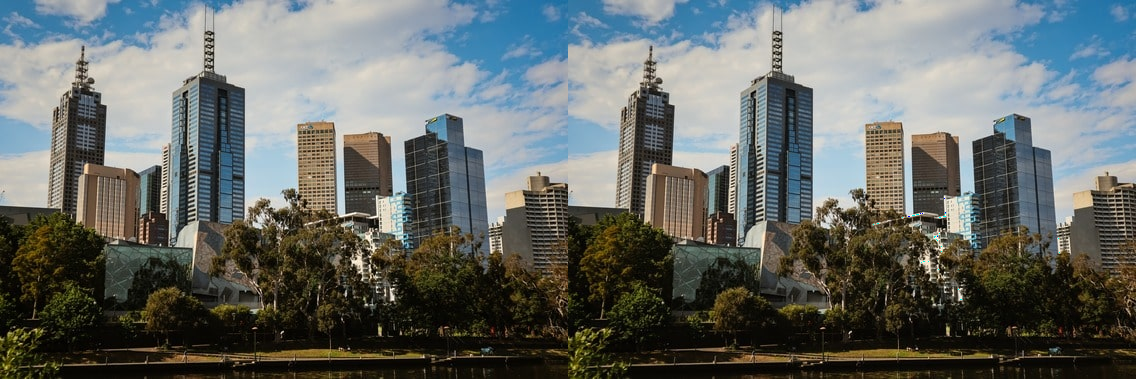

In [ ]:
# 1. IMPORT LIBRARY YANG DIBUTUHKAN (Ini yang belum ada di kode Anda)
import cv2 as cv
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 0 # Mencegah error jika input bukan angka

# 2. PROSES UPLOAD FILE (Ini yang ditambahkan)
print("\nSilakan pilih dan upload file gambar Anda:")
uploaded = files.upload()

# 3. MENGUBAH PATH SECARA OTOMATIS
if len(uploaded) > 0:
    # Mengambil nama file yang baru saja diupload
    nama_file = list(uploaded.keys())[0]
    path_gambar = '/content/' + nama_file
    print(f"\nFile berhasil diupload: {nama_file}")

    # 4. MEMBACA GAMBAR DARI HASIL UPLOAD
    original = cv.imread(path_gambar)

    if original is None:
        print("Error: Gambar gagal dibaca. Pastikan format file benar (jpg/png).")
    else:
        brightness_image = np.zeros(original.shape, original.dtype)

        # akses per piksel
        # np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
        for y in range(original.shape[0]):
            for x in range(original.shape[1]):
                for c in range(original.shape[2]):
                    brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

        # cara simpel no loop
        # brightness_image = cv.convertScaleAbs(original, beta=brightness)

        final_frame = cv.hconcat((original, brightness_image))

        # 5. MENAMPILKAN GAMBAR (cv2.imshow diganti cv2_imshow)
        cv2_imshow(final_frame)
else:
    print("Tidak ada file yang diupload.")

Dari potongan kode di atas dapat dilihat bahwa ketika dijalankan, system akan
menampilkan text field untuk memasukkan konstanta nilai brightness yang diinginkan,
dan akan disimpan pada variabel brightness. Kemudian ditentukan citra pada drive yang
akan diolah dan ditampung di variabel original. Tahap selanjutnya adalah mengakses
pixel citra masukan dengan 3 perulangan. Perulangan pertama dilakukan pada shape[0]
untuk tinggi citra, perulangan kedua dilakukan pada shape[1] untuk lebar citra, dan
perulangan ketiga dilakukan pada shape[2] yang merupakan channel warna pada citra.
Setelah melakukan 3 perulangan, dilakukan transformasi linier brightness dengan cara
menambahkan nilai brightness pada citra masukan. Contoh hasil dari kode program di
atas adalah sebagai berikut.

TUGAS PRAKTIKUM

1. Implementasi Inverse Citra
       <p> Rumus modul:

  $$ g(x,y)=255-f(x,y) $$

       

   Inverse menghasilkan citra negatif dengan membalik nilai pixel.

In [ ]:
original = cv.imread(base_path + 'peppers.jpg')

inverse = 255 - original

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(inverse, cv.COLOR_BGR2RGB))
plt.title('Inverse Citra')
plt.axis('off')

plt.show()

2.

3.

4.

5.

6.

7.

8.

9.

10.

11.
